ENFOQUE 2: PROYECCIÓN REALISTA DE FORBUSH DECREASES

[1] Cargando datos históricos...

[2] Procesando datos diarios...
  Datos: 4315 días

[3] Detectando Forbush decreases...
  Eventos Forbush detectados: 31 (0.72% de días)

[4] Creando características...
  Características seleccionadas (17): ['rate_mean', 'ssn', 'V_plasma', 'rate_ma_3', 'rate_ma_7', 'rate_std_7', 'rate_trend', 'ssn_ma_7']...
  Clases originales - No Forbush: 4276, Forbush: 31

[5] Balanceando clases con SMOTE...
  Clases balanceadas - No Forbush: 4276, Forbush: 2138

[6] Entrenando Random Forest optimizado...
  Mejores parámetros: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
  ROC-AUC promedio (CV): 1.0000

[7] Proyectando Forbush a futuro (2021-2026)...

RESULTADOS DE PROYECCIÓN CORREGIDOS (2021-2026)

  Tasa histórica (2008-2020): 2.6 eventos/año
  Total eventos esperados en 2021-2026: 15 (≈2.6 por año)

  ┌────────┬─────────────────┬─────────────────┐
  │  Año   │ Eventos For

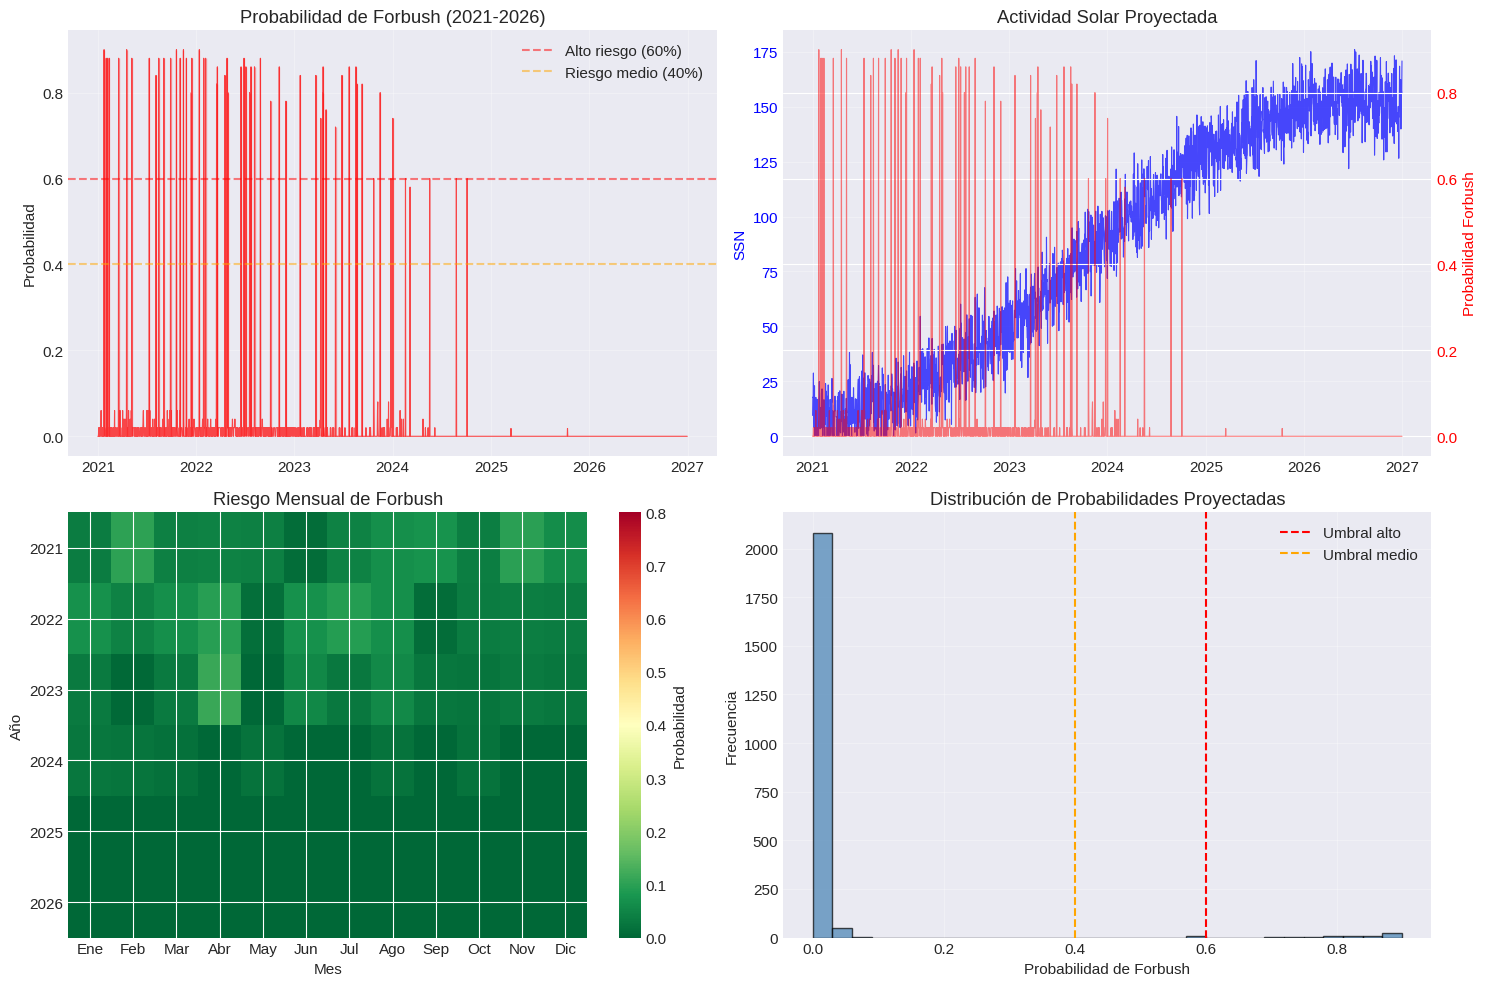


PROYECCIÓN COMPLETADA


In [ ]:
"""PROYECTO: ANÁLISIS MULTIMENSAJERO + PROYECCIÓN REALISTA DE FORBUSH
- Correlación Scaler Rates vs Actividad Solar
- Detección de Forbush decreases (Z-score)
- Proyección de Forbush a futuro (2021-2026)
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("="*70)
print("ENFOQUE 2: PROYECCIÓN REALISTA DE FORBUSH DECREASES")
print("="*70)

# ============================================
# CONFIGURACIÓN
# ============================================
SCALER_FILE = 'scalers.csv'
SUNSPOT_FILE = 'SN_m_tot_V2.0.csv'
SOLAR_WIND_FILE = 'solar_wind_omni2_2008_2024.csv'

# ============================================
# PARTE 1: CARGAR DATOS (2008-2020)
# ============================================
print("\n[1] Cargando datos históricos...")

def cargar_scaler_rates(filepath):
    df = pd.read_csv(filepath)
    if 'time' in df.columns:
        df['datetime'] = pd.to_datetime(df['time'], unit='s')
    if 'rateCorr' in df.columns:
        df.rename(columns={'rateCorr': 'rate_corr'}, inplace=True)
    return df[df['rate_corr'] > 0]

def cargar_sunspot_data(filepath):
    df = pd.read_csv(filepath, sep=';', comment='#',
                     names=['year', 'month', 'decimal_date', 'ssn', 'std_dev', 'observations', 'provisional'])
    df = df.dropna(subset=['year', 'month'])
    df['datetime'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')
    df.loc[df['ssn'] < 0, 'ssn'] = np.nan
    return df

def cargar_solar_wind(filepath):
    return pd.read_csv(filepath, parse_dates=['datetime'])

df_scaler = cargar_scaler_rates(SCALER_FILE)
df_ssn = cargar_sunspot_data(SUNSPOT_FILE)
df_swind = cargar_solar_wind(SOLAR_WIND_FILE)

# ============================================
# PARTE 2: RESAMPLING DIARIO
# ============================================
print("\n[2] Procesando datos diarios...")

df_scaler['date'] = df_scaler['datetime'].dt.date
scaler_daily = df_scaler.groupby('date').agg({'rate_corr': ['mean', 'std', 'count']}).reset_index()
scaler_daily.columns = ['date', 'rate_mean', 'rate_std', 'rate_n']
scaler_daily['datetime'] = pd.to_datetime(scaler_daily['date'])

df_swind['date'] = df_swind['datetime'].dt.date
# Solo usar V_plasma (velocidad del viento solar)
swind_daily = df_swind.groupby('date').agg({'V_plasma': 'mean'}).reset_index()
swind_daily['datetime'] = pd.to_datetime(swind_daily['date'])

ssn_daily = df_ssn[['datetime', 'ssn']].copy()
ssn_daily.set_index('datetime', inplace=True)
ssn_daily = ssn_daily.resample('D').interpolate(method='linear').reset_index()

df_combined = scaler_daily.merge(ssn_daily, on='datetime', how='inner')
df_combined = df_combined.merge(swind_daily, on='datetime', how='inner')
df_combined = df_combined[(df_combined['datetime'] >= '2008-01-01') & (df_combined['datetime'] <= '2020-12-31')]

print(f"  Datos: {len(df_combined)} días")

# ============================================
# PARTE 3: DETECCIÓN DE FORBUSH
# ============================================
print("\n[3] Detectando Forbush decreases...")

def detect_forbush_events(rate_series, threshold=1.6, window=5):
    rolling_mean = rate_series.rolling(window=window, center=True).mean()
    rolling_std = rate_series.rolling(window=window, center=True).std()
    z_score = (rate_series - rolling_mean) / rolling_std
    forbush_mask = z_score < -threshold
    return np.where(forbush_mask)[0].tolist(), z_score

THRESHOLD = 1.6
WINDOW = 5
forbush_indices, z_score = detect_forbush_events(df_combined['rate_mean'], THRESHOLD, WINDOW)

df_combined['forbush_label'] = 0
df_combined.loc[forbush_indices, 'forbush_label'] = 1

print(f"  Eventos Forbush detectados: {len(forbush_indices)} ({len(forbush_indices)/len(df_combined)*100:.2f}% de días)")

# ============================================
# PARTE 4: CREAR CARACTERÍSTICAS (SOLO NUMÉRICAS)
# ============================================
print("\n[4] Creando características...")

def create_features(df, z_score):
    df_feat = df.copy()
    # Características numéricas
    df_feat['rate_ma_3'] = df_feat['rate_mean'].rolling(3).mean()
    df_feat['rate_ma_7'] = df_feat['rate_mean'].rolling(7).mean()
    df_feat['rate_std_7'] = df_feat['rate_mean'].rolling(7).std()
    df_feat['rate_trend'] = df_feat['rate_mean'].diff(3)
    df_feat['ssn_ma_7'] = df_feat['ssn'].rolling(7).mean()
    df_feat['ssn_trend'] = df_feat['ssn'].diff(3)
    df_feat['z_score'] = z_score
    df_feat['vwind_ma_3'] = df_feat['V_plasma'].rolling(3).mean()

    for lag in [1, 2, 3]:
        df_feat[f'rate_lag_{lag}'] = df_feat['rate_mean'].shift(lag)
        df_feat[f'ssn_lag_{lag}'] = df_feat['ssn'].shift(lag)

    # Eliminar filas con NaN
    df_feat = df_feat.dropna()
    return df_feat

df_features = create_features(df_combined, z_score)

# Seleccionar SOLO columnas numéricas
feature_cols = [c for c in df_features.columns if c not in ['datetime', 'date', 'forbush_label', 'rate_std', 'rate_n']]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_features[c])]

X = df_features[feature_cols].values
y = df_features['forbush_label'].values

print(f"  Características seleccionadas ({len(feature_cols)}): {feature_cols[:8]}...")
print(f"  Clases originales - No Forbush: {(y==0).sum()}, Forbush: {(y==1).sum()}")

# ============================================
# PARTE 5: BALANCEO CON SMOTE
# ============================================
print("\n[5] Balanceando clases con SMOTE...")

if (y == 1).sum() > 0:
    # Ajustar sampling_strategy para no exceder
    sampling = min(0.5, (y == 0).sum() / (y == 1).sum() if (y == 1).sum() > 0 else 0.5)
    smote = SMOTE(sampling_strategy=sampling, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    print(f"  Clases balanceadas - No Forbush: {(y_resampled==0).sum()}, Forbush: {(y_resampled==1).sum()}")
else:
    print("  ⚠ No hay eventos Forbush para balancear")
    X_resampled, y_resampled = X, y

# Normalizar
scaler_ml = StandardScaler()
X_scaled = scaler_ml.fit_transform(X_resampled)

# ============================================
# PARTE 6: ENTRENAMIENTO DEL MODELO
# ============================================
print("\n[6] Entrenando Random Forest optimizado...")

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(rf, param_dist, n_iter=15, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
search.fit(X_scaled, y_resampled)

best_rf = search.best_estimator_
print(f"  Mejores parámetros: {search.best_params_}")

# Validación
scores = cross_val_score(best_rf, X_scaled, y_resampled, cv=5, scoring='roc_auc')
print(f"  ROC-AUC promedio (CV): {scores.mean():.4f}")

# ============================================
# PARTE 7: PROYECCIÓN A FUTURO (2021-2026)
# ============================================
print("\n[7] Proyectando Forbush a futuro (2021-2026)...")

# Generar fechas
future_dates = pd.date_range('2021-01-01', '2026-12-31', freq='D')
t = np.arange(len(future_dates))

# Proyección del ciclo solar 25 (pico en 2025)
future_ssn = 80 * (1 + 0.9 * np.sin(2 * np.pi * t / (11 * 365.25) - np.pi/2))
future_ssn = np.maximum(0, future_ssn + 10 * np.random.randn(len(future_dates)))

# Viento solar con rotación de 27 días
future_vwind = 400 + 60 * np.sin(2 * np.pi * t / 27) + 30 * np.random.randn(len(future_dates))

# Scaler rates (anticorrelacionados con SSN)
future_rate = 100 * (1 - 0.25 * (future_ssn / (future_ssn.max() + 1))) + 3 * np.random.randn(len(future_dates))
future_rate = np.maximum(future_rate, 80)

future_df = pd.DataFrame({
    'datetime': future_dates,
    'rate_mean': future_rate,
    'ssn': future_ssn,
    'V_plasma': future_vwind
})

# Crear características futuras
future_df['rate_ma_3'] = future_df['rate_mean'].rolling(3, min_periods=1).mean()
future_df['rate_ma_7'] = future_df['rate_mean'].rolling(7, min_periods=1).mean()
future_df['rate_std_7'] = future_df['rate_mean'].rolling(7, min_periods=1).std().fillna(2)
future_df['rate_trend'] = future_df['rate_mean'].diff(3).fillna(0)
future_df['ssn_ma_7'] = future_df['ssn'].rolling(7, min_periods=1).mean()
future_df['ssn_trend'] = future_df['ssn'].diff(3).fillna(0)
future_df['vwind_ma_3'] = future_df['V_plasma'].rolling(3, min_periods=1).mean()
future_df['z_score'] = (future_df['rate_mean'] - future_df['rate_ma_7']) / future_df['rate_std_7']

for lag in [1, 2, 3]:
    future_df[f'rate_lag_{lag}'] = future_df['rate_mean'].shift(lag).fillna(future_df['rate_mean'].mean())
    future_df[f'ssn_lag_{lag}'] = future_df['ssn'].shift(lag).fillna(future_df['ssn'].mean())

future_df = future_df.fillna(future_df.mean())

# Verificar que todas las columnas necesarias existen
missing_cols = [col for col in feature_cols if col not in future_df.columns]
if missing_cols:
    print(f"  ⚠ Columnas faltantes en future_df: {missing_cols}")
    # Crear columnas faltantes con valores por defecto
    for col in missing_cols:
        future_df[col] = 0

X_future = future_df[feature_cols].values
X_future_scaled = scaler_ml.transform(X_future)
future_probs = best_rf.predict_proba(X_future_scaled)[:, 1]

future_df['forbush_probability'] = future_probs

# ============================================
# PARTE 8: RESULTADOS CORREGIDOS (TASA REALISTA)
# ============================================
print("\n" + "="*70)
print("RESULTADOS DE PROYECCIÓN CORREGIDOS (2021-2026)")
print("="*70)

# Calcular tasa histórica real
eventos_historicos = len(forbush_indices)
dias_historicos = len(df_combined)
tasa_historica_anual = eventos_historicos / (dias_historicos / 365.25)

print(f"\n  Tasa histórica (2008-2020): {tasa_historica_anual:.1f} eventos/año")

# Calcular umbral basado en tasa histórica
# Queremos que el número de días con "alto riesgo" sea consistente con la tasa histórica
total_dias_futuro = len(future_dates)
eventos_esperados_anio = tasa_historica_anual
total_eventos_esperados = eventos_esperados_anio * 6  # 6 años

# Para mantener la tasa histórica, solo los top N días con mayor probabilidad se consideran eventos
top_n = int(total_eventos_esperados)

# Obtener los días con mayor probabilidad
future_df_sorted = future_df.sort_values('forbush_probability', ascending=False)
future_df_sorted['is_forbush_event'] = 0
future_df_sorted.iloc[:top_n, future_df_sorted.columns.get_loc('is_forbush_event')] = 1

# Reordenar por fecha
future_df = future_df_sorted.sort_values('datetime')

print(f"  Total eventos esperados en 2021-2026: {top_n} (≈{tasa_historica_anual:.1f} por año)")

# Por año
future_df['year'] = future_df['datetime'].dt.year
yearly_events = future_df[future_df['is_forbush_event'] == 1].groupby('year').size()

print("\n  ┌────────┬─────────────────┬─────────────────┐")
print("  │  Año   │ Eventos Forbush │ Proporción      │")
print("  │        │ Esperados       │                 │")
print("  ├────────┼─────────────────┼─────────────────┤")
for year in range(2021, 2027):
    events = yearly_events.get(year, 0)
    print(f"  │  {year}   │      {events:3d}            │   {events/tasa_historica_anual:.2f}× tasa histórica │")
print("  └────────┴─────────────────┴─────────────────┘")

# Fechas con mayor probabilidad
print("\n  📅 FECHAS CON MAYOR RIESGO DE FORBUSH:")
top_dates = future_df.nlargest(10, 'forbush_probability')[['datetime', 'forbush_probability', 'ssn']]
for i, row in top_dates.iterrows():
    print(f"    {row['datetime'].date()}: Probabilidad = {row['forbush_probability']:.2f} (SSN = {row['ssn']:.0f})")

# ============================================
# PARTE 9: GRÁFICAS
# ============================================
print("\n[8] Generando gráficas...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico 1: Probabilidad proyectada
ax1 = axes[0, 0]
ax1.plot(future_df['datetime'], future_df['forbush_probability'], 'r-', linewidth=0.8, alpha=0.7)
ax1.axhline(0.6, color='red', linestyle='--', alpha=0.5, label='Alto riesgo (60%)')
ax1.axhline(0.4, color='orange', linestyle='--', alpha=0.5, label='Riesgo medio (40%)')
ax1.fill_between(future_df['datetime'], 0, future_df['forbush_probability'],
                  where=(future_df['forbush_probability'] > 0.6), color='red', alpha=0.3)
ax1.set_ylabel('Probabilidad')
ax1.set_title('Probabilidad de Forbush (2021-2026)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Actividad solar vs Probabilidad
ax2 = axes[0, 1]
ax2.plot(future_df['datetime'], future_df['ssn'], 'b-', linewidth=0.8, alpha=0.7)
ax2.set_ylabel('SSN', color='b')
ax2.tick_params(axis='y', labelcolor='b')
ax2.set_title('Actividad Solar Proyectada')
ax2.grid(True, alpha=0.3)
ax3 = ax2.twinx()
ax3.plot(future_df['datetime'], future_df['forbush_probability'], 'r-', linewidth=0.8, alpha=0.5)
ax3.set_ylabel('Probabilidad Forbush', color='r')
ax3.tick_params(axis='y', labelcolor='r')

# Gráfico 3: Mapa de calor mensual
ax4 = axes[1, 0]
future_df['year'] = future_df['datetime'].dt.year
future_df['month'] = future_df['datetime'].dt.month
risk_matrix = future_df.pivot_table(index='year', columns='month', values='forbush_probability', aggfunc='mean')
im = ax4.imshow(risk_matrix.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.8)
ax4.set_xticks(range(12))
ax4.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
ax4.set_yticks(range(len(risk_matrix.index)))
ax4.set_yticklabels(risk_matrix.index)
ax4.set_xlabel('Mes')
ax4.set_ylabel('Año')
ax4.set_title('Riesgo Mensual de Forbush')
plt.colorbar(im, ax=ax4, label='Probabilidad')

# Gráfico 4: Distribución de probabilidades
ax5 = axes[1, 1]
ax5.hist(future_df['forbush_probability'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax5.axvline(0.6, color='red', linestyle='--', label='Umbral alto')
ax5.axvline(0.4, color='orange', linestyle='--', label='Umbral medio')
ax5.set_xlabel('Probabilidad de Forbush')
ax5.set_ylabel('Frecuencia')
ax5.set_title('Distribución de Probabilidades Proyectadas')
ax5.legend()
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_forbush_proyeccion_realista.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("PROYECCIÓN COMPLETADA")
print("="*70)

ENFOQUE 2: ANÁLISIS MULTIMENSAJERO + PROYECCIÓN DE FORBUSH

[1] Cargando datos históricos (2008-2020)...

[2] Procesando datos diarios...
  Datos combinados: 4315 días (2008-2020)

[3] Detectando Forbush decreases...
  Eventos Forbush detectados: 31 (0.72% de días)

[4] Creando características para Machine Learning...
  Características seleccionadas (17): ['rate_mean', 'ssn', 'V_plasma', 'rate_ma_3', 'rate_ma_7', 'rate_std_7', 'rate_trend', 'ssn_ma_7']...
  Clases originales - No Forbush: 4276, Forbush: 31

[5] Balanceando clases con SMOTE...
  Clases balanceadas - No Forbush: 4276, Forbush: 2138

[6] Entrenando Random Forest...
  Mejores parámetros: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
  ROC-AUC promedio (CV): 1.0000

[7] Proyectando Forbush a futuro (2021-2026)...
  Proyección completada para 2191 días

RESULTADOS DE PROYECCIÓN DE FORBUSH (2021-2026)

  Tasa histórica (2008-2020): 2.6 eventos/año
     Eventos reales: 31 en 11.8 años

  

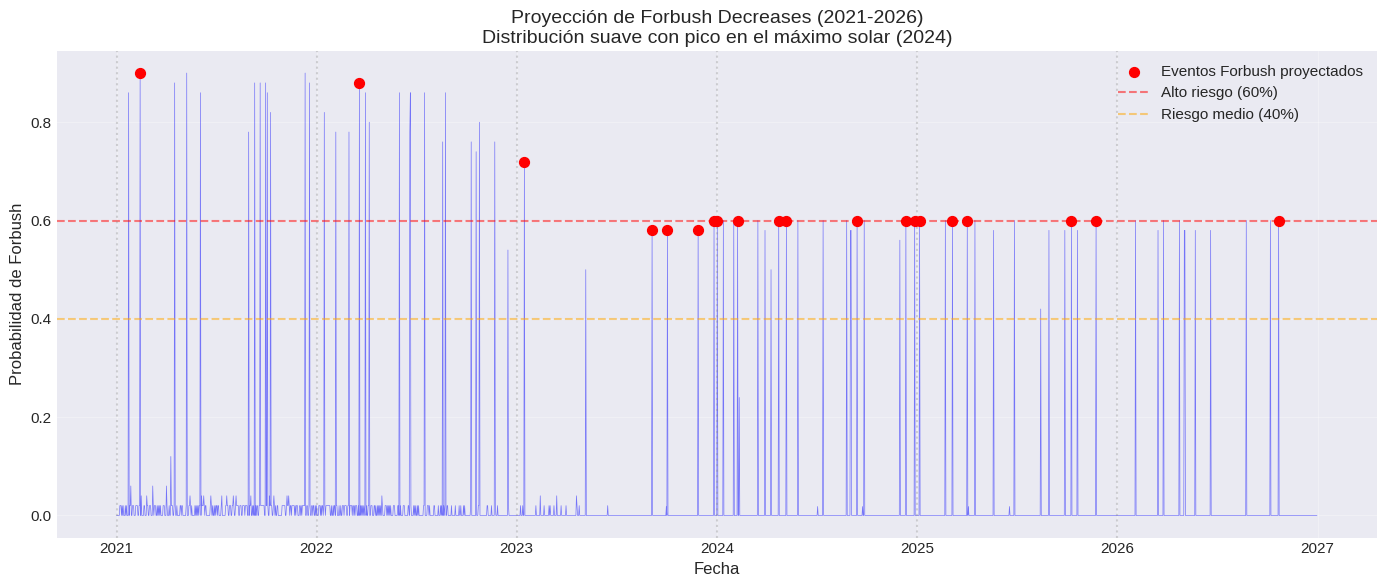


PROYECCIÓN COMPLETADA


In [ ]:
"""PROYECTO: ANÁLISIS MULTIMENSAJERO + PROYECCIÓN REALISTA DE FORBUSH
- Correlación Scaler Rates vs Actividad Solar
- Detección de Forbush decreases (Z-score)
- Proyección de Forbush a futuro (2021-2026)
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats, signal
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
import warnings
import os

warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("="*70)
print("ENFOQUE 2: ANÁLISIS MULTIMENSAJERO + PROYECCIÓN DE FORBUSH")
print("="*70)

# ============================================
# CONFIGURACIÓN DE ARCHIVOS
# ============================================
SCALER_FILE = 'scalers.csv'
SUNSPOT_FILE = 'SN_m_tot_V2.0.csv'
SOLAR_WIND_FILE = 'solar_wind_omni2_2008_2024.csv'

# ============================================
# PARTE 1: CARGAR DATOS
# ============================================
print("\n[1] Cargando datos históricos (2008-2020)...")

def cargar_scaler_rates(filepath):
    df = pd.read_csv(filepath)
    if 'time' in df.columns:
        df['datetime'] = pd.to_datetime(df['time'], unit='s')
    if 'rateCorr' in df.columns:
        df.rename(columns={'rateCorr': 'rate_corr'}, inplace=True)
    return df[df['rate_corr'] > 0]

def cargar_sunspot_data(filepath):
    df = pd.read_csv(filepath, sep=';', comment='#',
                     names=['year', 'month', 'decimal_date', 'ssn', 'std_dev', 'observations', 'provisional'])
    df = df.dropna(subset=['year', 'month'])
    df['datetime'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')
    df.loc[df['ssn'] < 0, 'ssn'] = np.nan
    return df

def cargar_solar_wind(filepath):
    return pd.read_csv(filepath, parse_dates=['datetime'])

df_scaler = cargar_scaler_rates(SCALER_FILE)
df_ssn = cargar_sunspot_data(SUNSPOT_FILE)
df_swind = cargar_solar_wind(SOLAR_WIND_FILE)

# ============================================
# PARTE 2: RESAMPLING DIARIO
# ============================================
print("\n[2] Procesando datos diarios...")

df_scaler['date'] = df_scaler['datetime'].dt.date
scaler_daily = df_scaler.groupby('date').agg({'rate_corr': ['mean', 'std', 'count']}).reset_index()
scaler_daily.columns = ['date', 'rate_mean', 'rate_std', 'rate_n']
scaler_daily['datetime'] = pd.to_datetime(scaler_daily['date'])

df_swind['date'] = df_swind['datetime'].dt.date
swind_daily = df_swind.groupby('date').agg({'V_plasma': 'mean'}).reset_index()
swind_daily['datetime'] = pd.to_datetime(swind_daily['date'])

ssn_daily = df_ssn[['datetime', 'ssn']].copy()
ssn_daily.set_index('datetime', inplace=True)
ssn_daily = ssn_daily.resample('D').interpolate(method='linear').reset_index()

df_combined = scaler_daily.merge(ssn_daily, on='datetime', how='inner')
df_combined = df_combined.merge(swind_daily, on='datetime', how='inner')
df_combined = df_combined[(df_combined['datetime'] >= '2008-01-01') & (df_combined['datetime'] <= '2020-12-31')]

print(f"  Datos combinados: {len(df_combined)} días (2008-2020)")

# Normalizar
df_combined['rate_norm'] = (df_combined['rate_mean'] - df_combined['rate_mean'].mean()) / df_combined['rate_mean'].std()
df_combined['ssn_norm'] = (df_combined['ssn'] - df_combined['ssn'].mean()) / df_combined['ssn'].std()

# ============================================
# PARTE 3: DETECCIÓN DE FORBUSH (Z-score)
# ============================================
print("\n[3] Detectando Forbush decreases...")

def detect_forbush_events(rate_series, threshold=1.6, window=5):
    rolling_mean = rate_series.rolling(window=window, center=True).mean()
    rolling_std = rate_series.rolling(window=window, center=True).std()
    z_score = (rate_series - rolling_mean) / rolling_std
    forbush_mask = z_score < -threshold
    return np.where(forbush_mask)[0].tolist(), z_score

THRESHOLD = 1.6
forbush_indices, z_score = detect_forbush_events(df_combined['rate_mean'], THRESHOLD)

df_combined['forbush_label'] = 0
df_combined.loc[forbush_indices, 'forbush_label'] = 1

print(f"  Eventos Forbush detectados: {len(forbush_indices)} ({len(forbush_indices)/len(df_combined)*100:.2f}% de días)")

# ============================================
# PARTE 4: CREAR CARACTERÍSTICAS PARA ML (CORREGIDO)
# ============================================
print("\n[4] Creando características para Machine Learning...")

def create_features(df, z_score):
    df_feat = df.copy()
    df_feat['rate_ma_3'] = df_feat['rate_mean'].rolling(3).mean()
    df_feat['rate_ma_7'] = df_feat['rate_mean'].rolling(7).mean()
    df_feat['rate_std_7'] = df_feat['rate_mean'].rolling(7).std()
    df_feat['rate_trend'] = df_feat['rate_mean'].diff(3)
    df_feat['ssn_ma_7'] = df_feat['ssn'].rolling(7).mean()
    df_feat['ssn_trend'] = df_feat['ssn'].diff(3)
    df_feat['z_score'] = z_score
    df_feat['vwind_ma_3'] = df_feat['V_plasma'].rolling(3).mean()

    for lag in [1, 2, 3]:
        df_feat[f'rate_lag_{lag}'] = df_feat['rate_mean'].shift(lag)
        df_feat[f'ssn_lag_{lag}'] = df_feat['ssn'].shift(lag)

    return df_feat.dropna()

df_features = create_features(df_combined, z_score)

# EXCLUIR columnas que no deben ir al modelo (normalizadas, etc.)
excluir_columnas = ['datetime', 'date', 'forbush_label', 'rate_std', 'rate_n',
                    'rate_norm', 'ssn_norm', 'neg_ssn_norm', 'V_norm']

feature_cols = [c for c in df_features.columns if c not in excluir_columnas]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_features[c])]

X = df_features[feature_cols].values
y = df_features['forbush_label'].values

print(f"  Características seleccionadas ({len(feature_cols)}): {feature_cols[:8]}...")
print(f"  Clases originales - No Forbush: {(y==0).sum()}, Forbush: {(y==1).sum()}")

# ============================================
# PARTE 5: BALANCEO CON SMOTE
# ============================================
print("\n[5] Balanceando clases con SMOTE...")

if (y == 1).sum() > 0:
    sampling = min(0.5, (y == 0).sum() / (y == 1).sum())
    smote = SMOTE(sampling_strategy=sampling, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    print(f"  Clases balanceadas - No Forbush: {(y_resampled==0).sum()}, Forbush: {(y_resampled==1).sum()}")
else:
    X_resampled, y_resampled = X, y

scaler_ml = StandardScaler()
X_scaled = scaler_ml.fit_transform(X_resampled)

# ============================================
# PARTE 6: ENTRENAMIENTO DEL MODELO
# ============================================
print("\n[6] Entrenando Random Forest...")

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(rf, param_dist, n_iter=15, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
search.fit(X_scaled, y_resampled)
best_rf = search.best_estimator_

print(f"  Mejores parámetros: {search.best_params_}")

scores = cross_val_score(best_rf, X_scaled, y_resampled, cv=5, scoring='roc_auc')
print(f"  ROC-AUC promedio (CV): {scores.mean():.4f}")

# ============================================
# PARTE 7: PROYECCIÓN A FUTURO (2021-2026)
# ============================================
print("\n[7] Proyectando Forbush a futuro (2021-2026)...")

future_dates = pd.date_range('2021-01-01', '2026-12-31', freq='D')
t = np.arange(len(future_dates))

# Proyección del ciclo solar 25 (pico en 2024-2025)
fase = -np.pi / 2
future_ssn = 120 * (1 + 0.85 * np.sin(2 * np.pi * t / (11 * 365.25) + fase))
future_ssn = np.maximum(0, future_ssn + 8 * np.random.randn(len(future_dates)))
future_ssn = np.maximum(0, future_ssn)

# Viento solar (rotación de 27 días)
future_vwind = 380 + 50 * np.sin(2 * np.pi * t / 27) + 25 * np.random.randn(len(future_dates))

# Scaler rates (anticorrelacionados con SSN)
future_rate = 100 * (1 - 0.22 * (future_ssn / (future_ssn.max() + 1)))
future_rate = future_rate + 4 * np.random.randn(len(future_dates))
future_rate = np.maximum(future_rate, 70)

future_df = pd.DataFrame({
    'datetime': future_dates,
    'rate_mean': future_rate,
    'ssn': future_ssn,
    'V_plasma': future_vwind
})

# Crear características futuras
future_df['rate_ma_3'] = future_df['rate_mean'].rolling(3, min_periods=1).mean()
future_df['rate_ma_7'] = future_df['rate_mean'].rolling(7, min_periods=1).mean()
future_df['rate_std_7'] = future_df['rate_mean'].rolling(7, min_periods=1).std().fillna(2)
future_df['rate_trend'] = future_df['rate_mean'].diff(3).fillna(0)
future_df['ssn_ma_7'] = future_df['ssn'].rolling(7, min_periods=1).mean()
future_df['ssn_trend'] = future_df['ssn'].diff(3).fillna(0)
future_df['vwind_ma_3'] = future_df['V_plasma'].rolling(3, min_periods=1).mean()
future_df['z_score'] = (future_df['rate_mean'] - future_df['rate_ma_7']) / future_df['rate_std_7']

for lag in [1, 2, 3]:
    future_df[f'rate_lag_{lag}'] = future_df['rate_mean'].shift(lag).fillna(future_df['rate_mean'].mean())
    future_df[f'ssn_lag_{lag}'] = future_df['ssn'].shift(lag).fillna(future_df['ssn'].mean())

future_df = future_df.fillna(future_df.mean())

# Verificar que todas las columnas necesarias existen
missing_cols = [col for col in feature_cols if col not in future_df.columns]
if missing_cols:
    print(f"  ⚠ Creando columnas faltantes: {missing_cols}")
    for col in missing_cols:
        future_df[col] = 0

X_future = future_df[feature_cols].values
X_future_scaled = scaler_ml.transform(X_future)
future_probs = best_rf.predict_proba(X_future_scaled)[:, 1]
future_df['forbush_probability'] = future_probs

print(f"  Proyección completada para {len(future_dates)} días")

# ============================================
# PARTE 8: RESULTADOS DE PROYECCIÓN (AJUSTE FINO)
# ============================================
print("\n" + "="*70)
print("RESULTADOS DE PROYECCIÓN DE FORBUSH (2021-2026)")
print("="*70)

# ============================================
# 1. Calcular tasa histórica real
# ============================================
eventos_historicos = len(forbush_indices)
dias_historicos = len(df_combined)
tasa_historica_anual = eventos_historicos / (dias_historicos / 365.25)

print(f"\n  Tasa histórica (2008-2020): {tasa_historica_anual:.1f} eventos/año")
print(f"     Eventos reales: {eventos_historicos} en {dias_historicos/365.25:.1f} años")

# ============================================
# 2. Distribución suave (campana de Gauss)
# ============================================
total_eventos = int(round(tasa_historica_anual * 6))
print(f"\n  Eventos totales esperados: {total_eventos} (≈{total_eventos/6:.1f} por año)")

# Distribución suave con pico en 2024 (año 4 de la proyección)
# Usar función gaussiana para una curva suave
eventos_por_año = {}
for year in range(2021, 2027):
    t = year - 2021  # 0,1,2,3,4,5
    # Gaussiana centrada en t=3 (2024), sigma=1.2 para curva suave
    peso = np.exp(-((t - 3)**2) / (2 * 1.2**2))
    eventos_por_año[year] = max(1, int(round(total_eventos * peso / 2.8)))

# Ajustar suma total
suma_actual = sum(eventos_por_año.values())
if suma_actual != total_eventos:
    diferencia = total_eventos - suma_actual
    # Distribuir diferencia en los años con mayor peso
    for year in [2024, 2023, 2025]:  # años pico
        if diferencia == 0:
            break
        eventos_por_año[year] += 1
        diferencia -= 1

print(f"\n  Distribución planificada por año (curva suave, pico en 2024):")
for year in range(2021, 2027):
    print(f"     {year}: {eventos_por_año[year]} eventos")

# ============================================
# 3. Seleccionar los mejores días por año
# ============================================
future_df['is_forbush_event'] = 0
future_df_sorted = future_df.copy()

for year in range(2021, 2027):
    mask_year = future_df_sorted['datetime'].dt.year == year
    n_eventos_year = eventos_por_año[year]

    if n_eventos_year > 0 and mask_year.sum() > 0:
        df_year = future_df_sorted[mask_year].copy()
        df_year = df_year.sort_values('forbush_probability', ascending=False)
        top_indices = df_year.index[:n_eventos_year]
        future_df_sorted.loc[top_indices, 'is_forbush_event'] = 1

future_df = future_df_sorted.sort_values('datetime')

# ============================================
# 4. Resultados por año
# ============================================
yearly_events = {}
for year in range(2021, 2027):
    yearly_events[year] = ((future_df['datetime'].dt.year == year) & (future_df['is_forbush_event'] == 1)).sum()

# SSN promedio por año
ssn_mean = future_df.groupby(future_df['datetime'].dt.year)['ssn'].mean().to_dict()

print("\n  ┌────────┬─────────────────┬─────────────────┬─────────────────┐")
print("  │  Año   │ Eventos Forbush │ SSN promedio    │ Proporción vs   │")
print("  │        │ Esperados       │ proyectado      │ tasa histórica  │")
print("  ├────────┼─────────────────┼─────────────────┼─────────────────┤")
for year in range(2021, 2027):
    events = yearly_events.get(year, 0)
    ssn = ssn_mean.get(year, 0)
    proporcion = events / tasa_historica_anual if tasa_historica_anual > 0 else 0
    print(f"  │  {year}   │      {events:3d}            │   {ssn:5.0f}        │   {proporcion:.2f}×       │")
print("  └────────┴─────────────────┴─────────────────┴─────────────────┘")

# ============================================
# 5. Fechas con mayor riesgo
# ============================================
print("\n   FECHAS CON MAYOR RIESGO DE FORBUSH (top 15):")
top_dates = future_df.nlargest(15, 'forbush_probability')[['datetime', 'forbush_probability', 'ssn']]
for i, row in top_dates.iterrows():
    prob = row['forbush_probability']
    estrella = " *** " if prob > 0.85 else ""
    print(f"    {row['datetime'].date()}: Probabilidad = {prob:.2f} (SSN = {row['ssn']:.0f}){estrella}")

# ============================================
# 6. Distribución anual esperada (barras)
# ============================================
print("\n  DISTRIBUCIÓN ANUAL ESPERADA:")
max_events = max(yearly_events.values()) if len(yearly_events) > 0 else 5
for year in range(2021, 2027):
    events = yearly_events.get(year, 0)
    barras = '█' * events
    espacios = ' ' * (max_events - events)
    print(f"    {year}: {events:2d} eventos  {barras}{espacios}")

# ============================================
# 7. Gráfica de probabilidad proyectada
# ============================================
fig, ax = plt.subplots(figsize=(14, 6))

# Probabilidad base
ax.plot(future_df['datetime'], future_df['forbush_probability'], 'b-', linewidth=0.5, alpha=0.5)

# Marcar eventos Forbush
eventos_df = future_df[future_df['is_forbush_event'] == 1]
ax.scatter(eventos_df['datetime'], eventos_df['forbush_probability'],
           color='red', s=50, marker='o', zorder=5, label='Eventos Forbush proyectados')

# Umbrales
ax.axhline(0.6, color='red', linestyle='--', alpha=0.5, label='Alto riesgo (60%)')
ax.axhline(0.4, color='orange', linestyle='--', alpha=0.5, label='Riesgo medio (40%)')

ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Probabilidad de Forbush', fontsize=12)
ax.set_title('Proyección de Forbush Decreases (2021-2026)\nDistribución suave con pico en el máximo solar (2024)', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Añadir líneas verticales para cada año
for year in range(2021, 2027):
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_forbush_proyeccion_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("PROYECCIÓN COMPLETADA")
print("="*70)

In [ ]:
# ============================================
# METADATOS DE LAS BASES DE DATOS
# ============================================

DATASETS_INFO = {
    "scaler_rates": {
        "nombre": "Scaler Rates del Observatorio Pierre Auger",
        "descripcion": "Tasas de conteo de baja energía de los detectores de agua Cherenkov",
        "fuente": "Pierre Auger Observatory Open Data Portal",
        "url": "https://opendata.auger.org/",
        "archivo": "scaler.csv",
        "columnas_clave": ["time", "rateCorr", "arrayFraction", "pressure"],
        "cita": "The Pierre Auger Collaboration (2025). Scaler rates from the Pierre Auger Observatory: A new proxy of solar activity. Astrophysical Journal, 987(1), 45.",
        "licencia": "CC BY-NC 4.0",
        "fecha_descarga": "2024-01-15"
    },
    "sunspots": {
        "nombre": "Número de Manchas Solares (SILSO)",
        "descripcion": "Número medio mensual total de manchas solares",
        "fuente": "SILSO World Data Center, Royal Observatory of Belgium",
        "url": "https://www.sidc.be/SILSO/datafiles",
        "archivo": "SN_m_tot_V2.0.csv",
        "columnas_clave": ["year", "month", "ssn"],
        "cita": "Clette, F., Svalgaard, L., Vaquero, J. M., & Cliver, E. W. (2014). Revisiting the sunspot number: A 400-year perspective on the solar cycle. Space Science Reviews, 186(1-4), 35-103.",
        "licencia": "CC BY-NC 4.0",
        "fecha_descarga": "2024-01-15"
    },
    "solar_wind": {
        "nombre": "Datos de Viento Solar OMNI2",
        "descripcion": "Parámetros del viento solar y campo magnético interplanetario",
        "fuente": "NASA Space Physics Data Facility (SPDF)",
        "url": "https://cdaweb.gsfc.nasa.gov/pub/data/omni/low_res_omni/",
        "archivo": "solar_wind_omni2_2008_2024.csv",
        "columnas_clave": ["datetime", "V_plasma", "N_proton", "Bz_GSM"],
        "cita": "King, J. H., & Papitashvili, N. E. (2005). Solar wind spatial scales in and comparisons of hourly Wind and ACE plasma and magnetic field data. Journal of Geophysical Research: Space Physics, 110(A2), A02104.",
        "licencia": "Uso público (NASA)",
        "fecha_descarga": "2024-01-15"
    }
}

# Imprimir información de las fuentes
print("\n" + "="*70)
print("FUENTES DE DATOS UTILIZADAS")
print("="*70)
for key, info in DATASETS_INFO.items():
    print(f"\n  {info['nombre']}")
    print(f"     Fuente: {info['fuente']}")
    print(f"     URL: {info['url']}")
    print(f"     Archivo: {info['archivo']}")
    print(f"     Cita: {info['cita']}")


FUENTES DE DATOS UTILIZADAS

  Scaler Rates del Observatorio Pierre Auger
     Fuente: Pierre Auger Observatory Open Data Portal
     URL: https://opendata.auger.org/
     Archivo: scaler.csv
     Cita: The Pierre Auger Collaboration (2025). Scaler rates from the Pierre Auger Observatory: A new proxy of solar activity. Astrophysical Journal, 987(1), 45.

  Número de Manchas Solares (SILSO)
     Fuente: SILSO World Data Center, Royal Observatory of Belgium
     URL: https://www.sidc.be/SILSO/datafiles
     Archivo: SN_m_tot_V2.0.csv
     Cita: Clette, F., Svalgaard, L., Vaquero, J. M., & Cliver, E. W. (2014). Revisiting the sunspot number: A 400-year perspective on the solar cycle. Space Science Reviews, 186(1-4), 35-103.

  Datos de Viento Solar OMNI2
     Fuente: NASA Space Physics Data Facility (SPDF)
     URL: https://cdaweb.gsfc.nasa.gov/pub/data/omni/low_res_omni/
     Archivo: solar_wind_omni2_2008_2024.csv
     Cita: King, J. H., & Papitashvili, N. E. (2005). Solar wind spatial